# Mesh Generation

**THE BASE STATION LOCATION HASN'T BEEN PROVIDED!!!**

**Frequency range:**

* MT: Just use 10 Hz to 1,000 Hz. Gives a little extra bandwidth but covers the range of the airborne
* ZTEM: Has frequencies about 25, 50, 100, 200, 400, 800 Hz (but not those exact numbers)
* AppCon: Has frequencies over the range of 25 Hz - 800 Hz, then jumps to high frequencies. I don't like the higher frequencies and they are dominated by the effect of topography.

**Minimum cell size:**

We were told that stations were located at the center of 25 m x 25 m cells when the original data were simulated. So we shouldn't deviate from the origina discretization. The real question is whether we use cubic cells or decrease the vertical thickness to 12.5 m.

In [1]:
import numpy as np
import os
from discretize import TreeMesh, TensorMesh
from discretize.utils import active_from_xyz

from simpeg.utils import get_discrete_topography, shift_to_discrete_topography

from scipy.interpolate import LinearNDInterpolator

from matplotlib import pyplot as plt
import matplotlib as mpl

In [2]:
in_dir = './part_1_outputs/'
out_dir = './part_3_outputs/'

if not os.path.exists(out_dir):
    os.mkdir(out_dir)

## Notebook Parameters

In [3]:
use_mt = True
use_ztem = True
use_appcon = True

f_min = 10.
f_max = 1000.

rho_min = 1
rho_max = 1000

xmin, xmax = 3475., 1e8
ymin, ymax = 2475., 1e8

In [4]:
500 * np.sqrt(rho_min / f_max)

15.811388300841896

In [5]:
500 * np.sqrt(rho_max / f_min)

5000.0

## Load Files

In [6]:
locations_mt = np.load(in_dir + 'locations_mt.npy')
locations_ztem = np.load(in_dir + 'locations_ztem.npy')
locations_appcon = np.load(in_dir + 'locations_appcon.npy')
location_base = np.load(in_dir + 'location_base.npy')

frequencies_mt = np.load(in_dir + 'frequencies_mt.npy')
frequencies_ztem = np.load(in_dir + 'frequencies_ztem.npy')
frequencies_appcon = np.load(in_dir + 'frequencies_appcon.npy')

topo_xyz = np.loadtxt('./elevation/elevation.txt')

In [7]:
print([frequencies_mt.min(), frequencies_mt.max()])

[10.0, 25118.8]


In [8]:
print([frequencies_ztem.min(), frequencies_ztem.max()])

[25.10002, 794.3001]


In [9]:
print([frequencies_appcon.min(), frequencies_appcon.max()])

[25.10002, 15848.89]


## Extract Desired Locations

In [10]:
inds = (locations_mt[:, 0] >= xmin) & (locations_mt[:, 0] <= xmax) & (locations_mt[:, 1] >= ymin) & (locations_mt[:, 1] <= ymax)
locations_mt_ne = locations_mt[inds, :]

inds = (locations_ztem[:, 0] >= xmin) & (locations_ztem[:, 0] <= xmax) & (locations_ztem[:, 1] >= ymin) & (locations_ztem[:, 1] <= ymax)
locations_ztem_ne = locations_ztem[inds, :]

inds = (locations_appcon[:, 0] >= xmin) & (locations_appcon[:, 0] <= xmax) & (locations_appcon[:, 1] >= ymin) & (locations_appcon[:, 1] <= ymax)
locations_appcon_ne = locations_appcon[inds, :]

## Design Mesh

In [11]:
dx, dy, dz = 25, 25, 25  # base cell width
dom_width_x = 64000.0  # domain width x
dom_width_y = 64000.0  # domain width x
dom_width_z = 64000.0  # domain width z
nbcx = 2 ** int(np.round(np.log(dom_width_x / dx) / np.log(2.0)) + 1)  # num. base cells x
nbcy = 2 ** int(np.round(np.log(dom_width_y / dy) / np.log(2.0)) + 1)  # num. base cells y
nbcz = 2 ** int(np.round(np.log(dom_width_z / dz) / np.log(2.0)) + 1)  # num. base cells z

# Define the base mesh with top at z = 0 m.
hx = [(dx, nbcx)]
hy = [(dy, nbcy)]
hz = [(dz, nbcz)]
mesh = TreeMesh([hx, hy, hz], x0='CCC', diagonal_balance=True)
mesh_ne = TreeMesh([hx, hy, hz], x0='CCC', diagonal_balance=True)

# NO SHIFTING ORIGIN!!!

In [12]:
mesh.refine_points(
    locations_mt, padding_cells_by_level=[3, 3], finalize=False
)
mesh.refine_points(
    locations_ztem, padding_cells_by_level=[3, 3], finalize=False
)
mesh.refine_points(
    location_base.reshape((1, 3)), padding_cells_by_level=[3, 3, 3, 3], finalize=False
)
mesh.refine_surface(
    locations_mt + np.r_[0, 0, 25], padding_cells_by_level=[6, 7, 7, 4, 2, 2], finalize=False,
)
mesh.finalize()

print('Number of cells: {}'.format(mesh.nC))

TreeMesh.write_UBC(mesh, out_dir+'octree_mesh_unreg.txt')
os.system(
    'regularizeOctreeMesh.exe '+
    out_dir + 'octree_mesh_unreg.txt ' +
    out_dir + 'octree_mesh.txt'
)
mesh = TreeMesh.read_UBC(out_dir+'octree_mesh.txt')

print('Number of cells: {}'.format(mesh.nC))

Number of cells: 1321279
Number of cells: 1342398


In [13]:
mesh_ne.refine_points(
    locations_mt_ne, padding_cells_by_level=[3, 3], finalize=False
)
mesh_ne.refine_points(
    locations_ztem_ne, padding_cells_by_level=[3, 3], finalize=False
)
mesh_ne.refine_points(
    location_base.reshape((1, 3)), padding_cells_by_level=[3, 3, 3, 3], finalize=False
)
mesh_ne.refine_surface(
    locations_mt_ne + np.r_[0, 0, 25], padding_cells_by_level=[6, 7, 7, 4, 2, 2], finalize=False,
)
mesh_ne.finalize()

print('Number of cells: {}'.format(mesh_ne.nC))

TreeMesh.write_UBC(mesh_ne, out_dir+'octree_mesh_unreg.txt')
os.system(
    'regularizeOctreeMesh.exe '+
    out_dir + 'octree_mesh_unreg.txt ' +
    out_dir + 'octree_mesh_ne.txt'
)
mesh_ne = TreeMesh.read_UBC(out_dir+'octree_mesh_ne.txt')

print('Number of cells: {}'.format(mesh_ne.nC))

Number of cells: 436535
Number of cells: 449450


## Active Cells

In [14]:
active_cells = active_from_xyz(mesh, topo_xyz)
active_cells_ne = active_from_xyz(mesh_ne, topo_xyz)

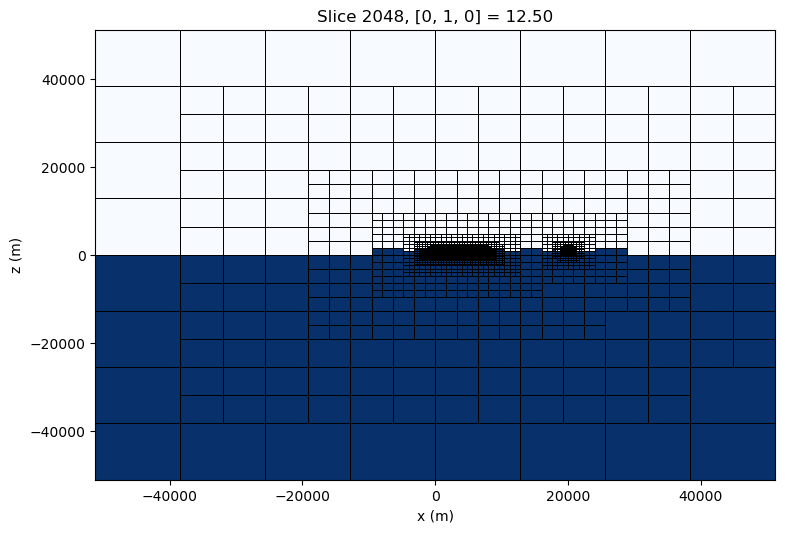

In [15]:
fig = plt.figure(figsize=(10, 6))

ax1 = fig.add_axes([0.15, 0.15, 0.68, 0.75])
mesh.plot_slice(
    active_cells.copy(),
    ax=ax1,
    normal="Y",
    ind=int(len(mesh.h[1]) / 2),
    grid=True,
    pcolor_opts={"cmap": mpl.cm.Blues},
    grid_opts={"color": "k", "linewidth": 0.5}
)
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")
# ax1.set_xlim([-2000, 2000])
# ax1.set_ylim([-1200, 400])

plt.show()

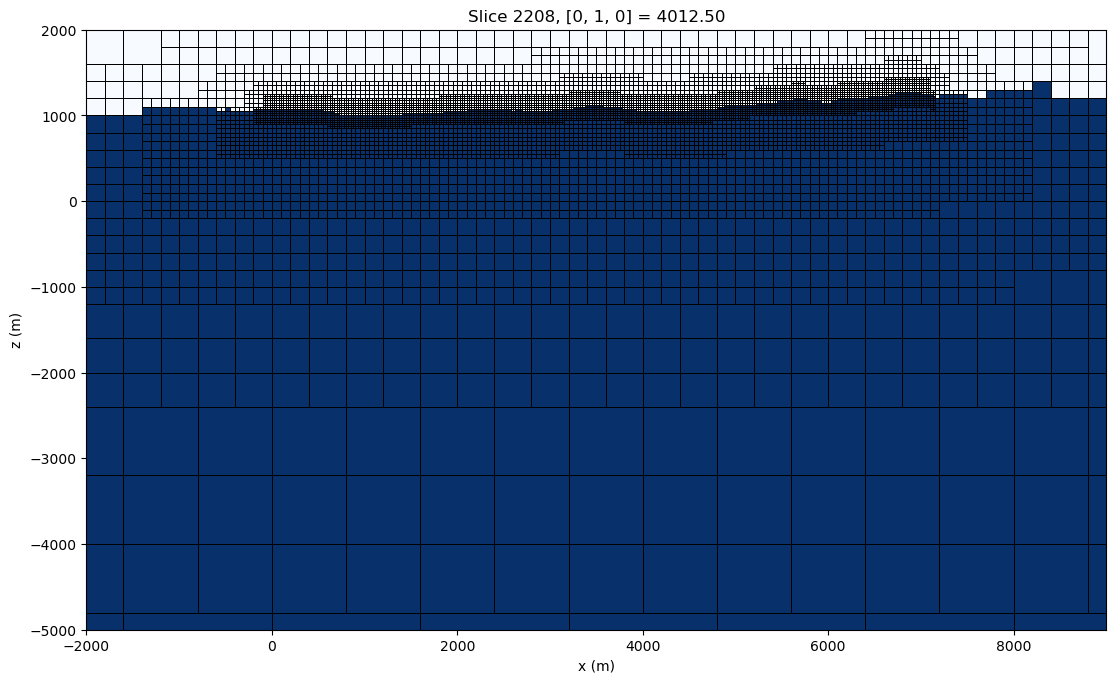

In [16]:
fig = plt.figure(figsize=(15, 8))

ax1 = fig.add_axes([0.15, 0.15, 0.68, 0.75])
mesh.plot_slice(
    active_cells.copy(),
    ax=ax1,
    normal="Y",
    ind=int(len(mesh.h[1]) / 2 + 4000 // 25),
    grid=True,
    pcolor_opts={"cmap": mpl.cm.Blues},
    grid_opts={"color": "k", "linewidth": 0.5}
)
# ax1.scatter(center_point[0], center_point[2], 3, 'r')
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")
ax1.set_xlim([-2000, 9000])
ax1.set_ylim([-5000, 2000])

plt.show()

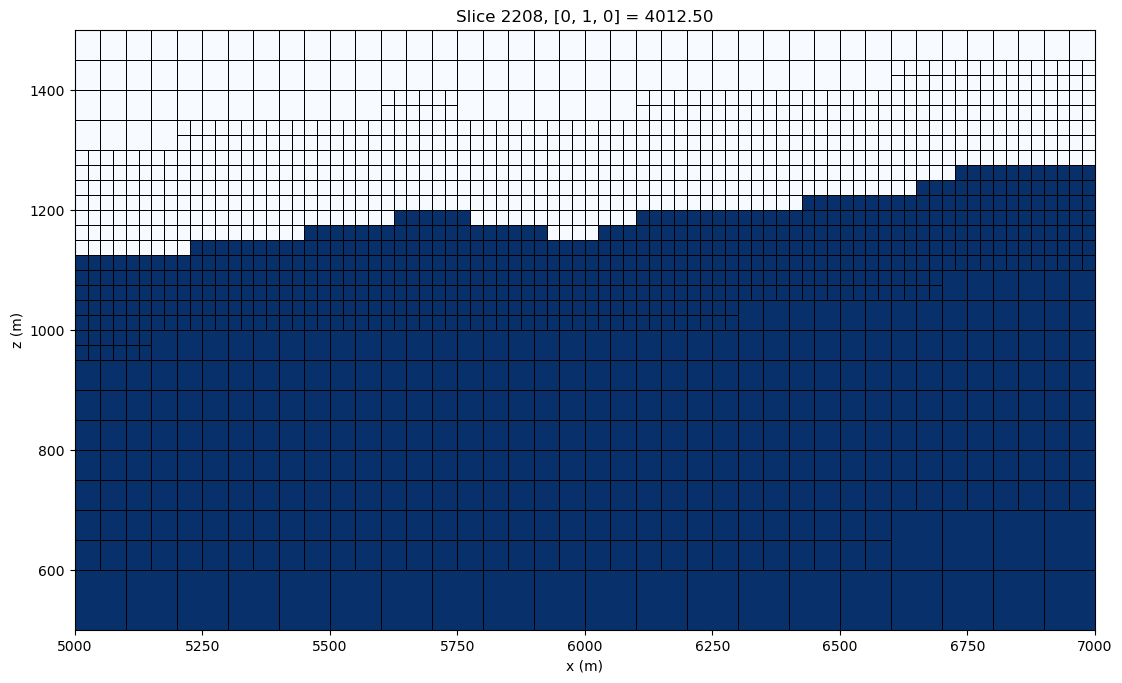

In [17]:
fig = plt.figure(figsize=(15, 8))

ax1 = fig.add_axes([0.15, 0.15, 0.68, 0.75])
mesh.plot_slice(
    active_cells.copy(),
    ax=ax1,
    normal="Y",
    ind=int(len(mesh.h[1]) / 2 + 4000/25),
    grid=True,
    pcolor_opts={"cmap": mpl.cm.Blues},
    grid_opts={"color": "k", "linewidth": 0.5}
)
# ax1.scatter(center_point[0], center_point[2], 3, 'r')
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")
ax1.set_xlim([5000, 7000])
ax1.set_ylim([500, 1500])

plt.show()

## Shift to Discrete Topography

In [18]:
locations_mt_shifted = shift_to_discrete_topography(mesh, locations_mt, active_cells, shift_horizontal=True, heights=0.)

locations_ztem_shifted = shift_to_discrete_topography(mesh, locations_ztem, active_cells, shift_horizontal=True, heights=100.)

locations_appcon_shifted = shift_to_discrete_topography(mesh, locations_appcon, active_cells, shift_horizontal=True, heights=100.)

location_base_shifted = shift_to_discrete_topography(mesh, np.outer(np.ones(2), location_base), active_cells, shift_horizontal=True, heights=0)
location_base_shifted = location_base_shifted[0, :].reshape((1, 3))

## 1D Model

In [19]:
air_conductivity = 1e-8
host_conductivity = 0.02
zc_1d = 0.  # elevation where discrete surface meets mesh boundary

In [20]:
# Same for both tree meshes since base mesh the same
hz_1d = mesh.h[2]
mesh_1d = TensorMesh([hz_1d], origin=np.array([mesh.origin[-1]]))
sigma_1d = air_conductivity * np.ones(mesh_1d.n_cells)
sigma_1d[mesh_1d.cell_centers < zc_1d] = host_conductivity

## Export

In [21]:
np.save(out_dir + '/locations_mt_shifted.npy', locations_mt_shifted)
np.save(out_dir + '/locations_ztem_shifted.npy', locations_ztem_shifted)
np.save(out_dir + '/locations_appcon_shifted.npy', locations_appcon_shifted)
np.save(out_dir + '/location_base_shifted.npy', location_base_shifted)

np.save(out_dir + '/sigma_1d.npy', sigma_1d)

np.save(out_dir + 'active_cells.npy', active_cells)
np.save(out_dir + 'active_cells_ne.npy', active_cells_ne)